# Análise de Dados de Viagens – 2025

## 1. Introdução

Este projeto tem como objetivo analisar os dados de viagens de 2025, utilizando Python, SQL e PostgreSQL.

Os dados foram organizados seguindo a arquitetura Medallion, dividida nas camadas RAW, SILVER e GOLD.

A análise busca identificar padrões relacionados às viagens, custos, pagamentos, meios de transporte e destinos.

## 2. Objetivos

- Analisar os dados de viagens de 2025.
- Identificar os órgãos com maiores custos.
- Analisar os custos médios por destino.
- Identificar a viagem com maior duração.
- Analisar os tipos de pagamento.
- Identificar os meios de transporte e UFs de destino mais frequentes.
- Criar visualizações para facilitar a interpretação dos resultados.

## 3. Ferramentas utilizadas

- Python
- Pandas
- PostgreSQL
- SQLAlchemy
- Matplotlib
- Seaborn

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import text
from banco import engine

print("Conexão com o PostgreSQL configurada!")

Conexão com o PostgreSQL configurada!


In [29]:
def moeda(valor):
    return (
        f"R$ {valor:,.2f}"
        .replace(",", "X")
        .replace(".", ",")
        .replace("X", ".")
    )

## 4. Perguntas de negócio

As análises abaixo respondem às sete perguntas de negócio definidas para o projeto.

Todas as consultas consideram somente viagens com situação igual a "Realizada".

### 4.1 Quais 5 órgãos têm maior custo total?

In [31]:
consulta_1 = text("""
SELECT
    nome_orgao_superior AS orgao,
    SUM(valor_total) AS custo_total
FROM public.silver_viagem
WHERE situacao = 'Realizada'
GROUP BY nome_orgao_superior
ORDER BY custo_total DESC
LIMIT 5;
""")

df_1 = pd.read_sql(consulta_1, engine)

df_1_exibicao = df_1.copy()
df_1_exibicao["custo_total"] = df_1_exibicao["custo_total"].apply(moeda)

display(df_1_exibicao)

,orgao,custo_total
0,Ministério da Justiça e Segurança Pública,"R$ 485.748.241,43"
1,Ministério da Defesa,"R$ 154.595.910,29"
2,Ministério da Educação,"R$ 109.759.836,03"
3,Ministério do Meio Ambiente e Mudança do Clima,"R$ 49.300.595,26"
4,Ministério da Previdência Social,"R$ 40.236.180,79"


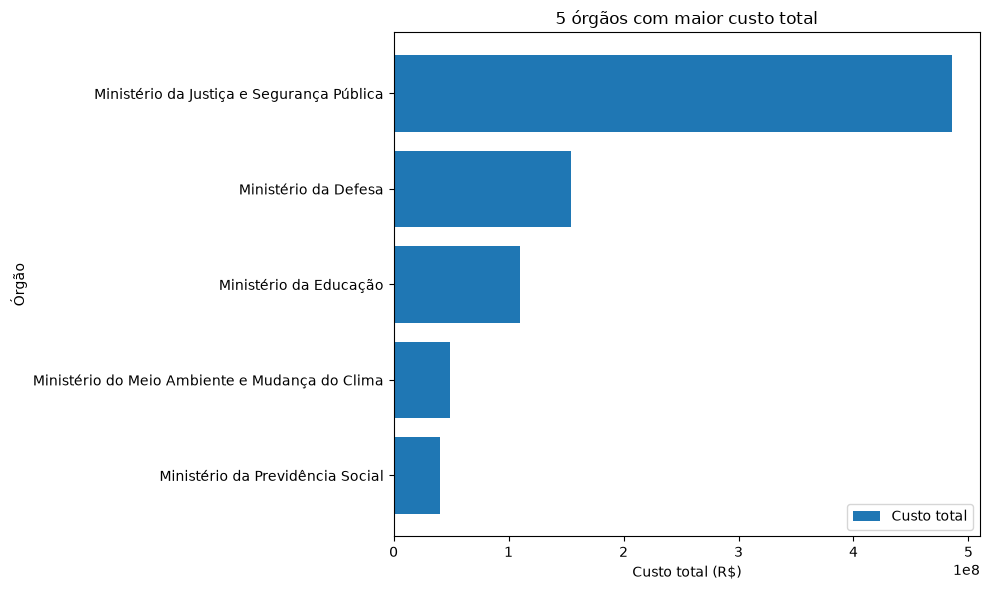

In [32]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_1["orgao"][::-1],
    df_1["custo_total"][::-1],
    label="Custo total"
)

plt.title("5 órgãos com maior custo total")
plt.xlabel("Custo total (R$)")
plt.ylabel("Órgão")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão

O Ministério da Justiça e Segurança Pública apresentou o maior custo total, seguido pelo Ministério da Defesa, Ministério da Educação, Ministério do Meio Ambiente e Mudança do Clima e Ministério da Previdência Social.

## 4.2 Quais 3 destinos têm maior custo médio por viagem?

In [33]:
consulta_2 = text("""
SELECT
    destinos,
    SUM(valor_total) / COUNT(*) AS custo_medio,
    COUNT(*) AS viagens
FROM public.silver_viagem
WHERE situacao = 'Realizada'
GROUP BY destinos
HAVING COUNT(*) >= 100
ORDER BY custo_medio DESC
LIMIT 3;
""")

df_2 = pd.read_sql(consulta_2, engine)

df_2_exibicao = df_2.copy()
df_2_exibicao["custo_medio"] = df_2_exibicao["custo_medio"].apply(moeda)

display(df_2_exibicao)

,destinos,custo_medio,viagens
0,"Brasília/DF, Brasília/DF","R$ 27.401,80",283
1,Genebra/Suíça,"R$ 25.469,22",242
2,Nova York/Estados Unidos da América,"R$ 21.214,19",149


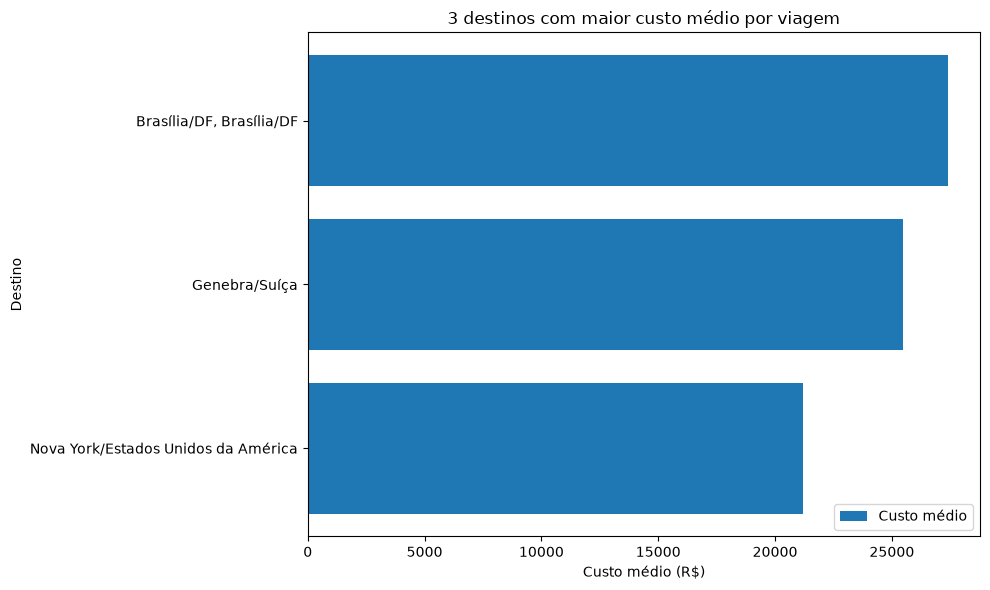

In [34]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_2["destinos"][::-1],
    df_2["custo_medio"][::-1],
    label="Custo médio"
)

plt.title("3 destinos com maior custo médio por viagem")
plt.xlabel("Custo médio (R$)")
plt.ylabel("Destino")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão

Entre os destinos com pelo menos 100 viagens realizadas, Brasília/DF, Brasília/DF apresentou o maior custo médio por viagem, seguida por Genebra/Suíça e Nova York/Estados Unidos.

### 4.3 Qual viagem tem maior duração e qual foi seu custo total?

In [35]:
consulta_3 = text("""
SELECT
    id_viagem,
    destinos,
    nome_orgao_superior AS orgao,
    duracao_dias,
    valor_total AS custo_total
FROM public.silver_viagem
WHERE situacao = 'Realizada'
  AND duracao_dias IS NOT NULL
ORDER BY duracao_dias DESC
LIMIT 1;
""")

df_3 = pd.read_sql(consulta_3, engine)

df_3_exibicao = df_3.copy()
df_3_exibicao["custo_total"] = df_3_exibicao["custo_total"].apply(moeda)

display(df_3_exibicao)

,id_viagem,destinos,orgao,duracao_dias,custo_total
0,0000000000020699856,Mogi Mirim/SP,Ministério da Previdência Social,384,"R$ 0,00"


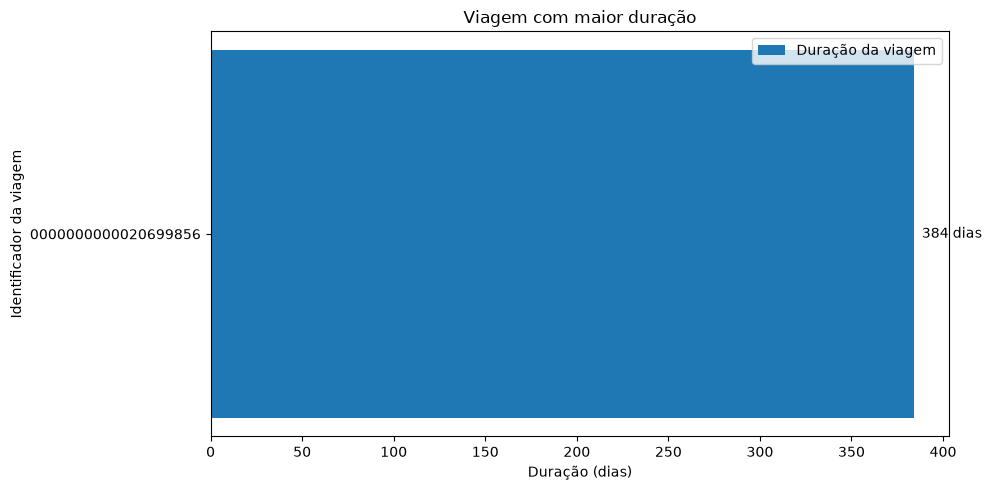

In [37]:
plt.figure(figsize=(10, 5))

plt.barh(
    [str(df_3["id_viagem"].iloc[0])],
    [df_3["duracao_dias"].iloc[0]],
    label="Duração da viagem"
)

plt.title("Viagem com maior duração")
plt.xlabel("Duração (dias)")
plt.ylabel("Identificador da viagem")
plt.legend()

plt.text(
    df_3["duracao_dias"].iloc[0],
    0,
    f'  {df_3["duracao_dias"].iloc[0]} dias',
    va="center"
)

plt.tight_layout()
plt.show()

### Conclusão

A viagem com maior duração apresentou 384 dias. O destino registrado foi Mogi Mirim/SP e o custo total registrado foi de R$ 0,00.

## 4.4 Qual tipo de pagamento tem maior valor médio?

In [38]:
consulta_4 = text("""
SELECT
    tipo_pagamento,
    SUM(p.valor) / COUNT(*) AS valor_medio
FROM public.silver_pagamento p
JOIN public.silver_viagem v
    ON p.id_viagem = v.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY tipo_pagamento
ORDER BY valor_medio DESC;
""")

df_4 = pd.read_sql(consulta_4, engine)

df_4_exibicao = df_4.copy()
df_4_exibicao["valor_medio"] = df_4_exibicao["valor_medio"].apply(moeda)

display(df_4_exibicao)

,tipo_pagamento,valor_medio
0,DIÁRIAS,"R$ 2.078,79"
1,PASSAGEM,"R$ 1.882,32"
2,Serviço correlato: seguro,"R$ 447,26"
3,RESTITUIÇÃO,"R$ 245,70"


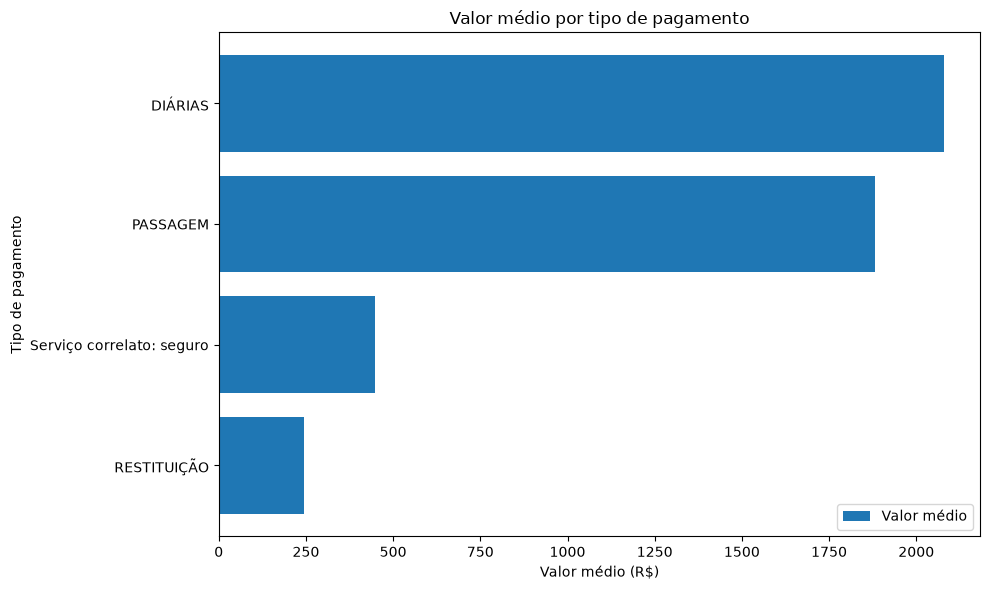

In [39]:
plt.figure(figsize=(10, 6))

plt.barh(
    df_4["tipo_pagamento"][::-1],
    df_4["valor_medio"][::-1],
    label="Valor médio"
)

plt.title("Valor médio por tipo de pagamento")
plt.xlabel("Valor médio (R$)")
plt.ylabel("Tipo de pagamento")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão

As diárias apresentaram o maior valor médio entre os tipos de pagamento analisados, com valor médio de R$ 2.078,79.

### 4.5 Qual meio de transporte é mais utilizado nos trechos?

In [40]:
consulta_5 = text("""
SELECT
    t.meio_transporte,
    COUNT(*) AS quantidade
FROM public.silver_trecho t
JOIN public.silver_viagem v
    ON t.id_viagem = v.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY t.meio_transporte
ORDER BY quantidade DESC;
""")

df_5 = pd.read_sql(consulta_5, engine)

display(df_5)

,meio_transporte,quantidade
0,Veículo Oficial,385734
1,Aéreo,226707
2,Rodoviário,64454
3,Veículo Próprio,42736
4,Inválido,26523
5,Fluvial,8392
6,Ferroviário,868
7,Marítimo,471


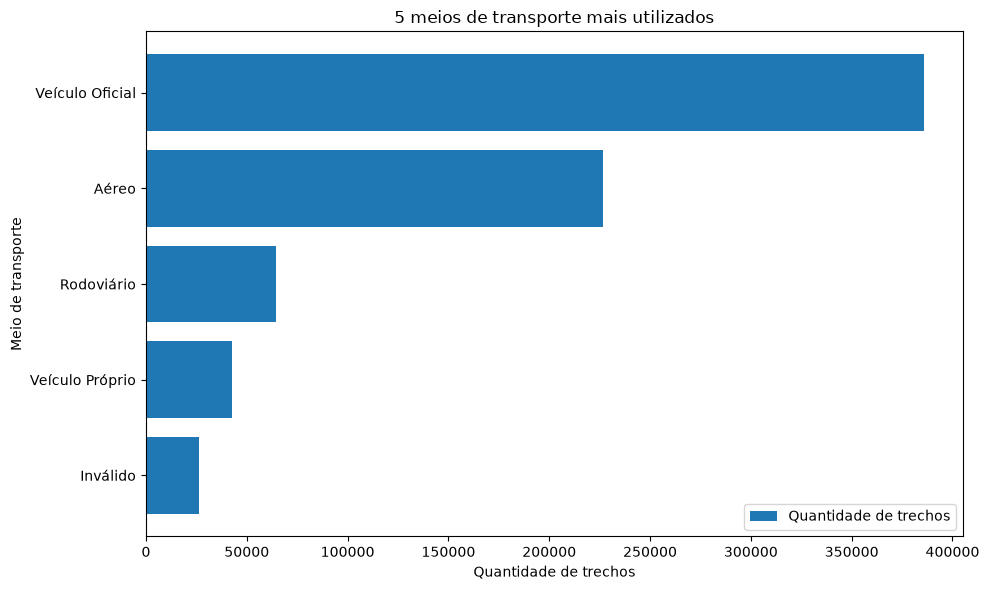

In [41]:
df_5_grafico = df_5.head(5)

plt.figure(figsize=(10, 6))

plt.barh(
    df_5_grafico["meio_transporte"][::-1],
    df_5_grafico["quantidade"][::-1],
    label="Quantidade de trechos"
)

plt.title("5 meios de transporte mais utilizados")
plt.xlabel("Quantidade de trechos")
plt.ylabel("Meio de transporte")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão

O Veículo Oficial foi o meio de transporte mais utilizado nos trechos das viagens realizadas, com 385.734 registros.

### 4.6 Qual UF de destino aparece mais nos trechos?

In [42]:
consulta_6 = text("""
SELECT
    t.destino_uf,
    COUNT(*) AS quantidade
FROM public.silver_trecho t
JOIN public.silver_viagem v
    ON t.id_viagem = v.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY t.destino_uf
ORDER BY quantidade DESC;
""")

df_6 = pd.read_sql(consulta_6, engine)

display(df_6)

,destino_uf,quantidade
0,São Paulo,81727
1,Distrito Federal,77962
2,Minas Gerais,50555
3,Rio de Janeiro,43481
4,Paraná,42323
5,Pará,39742
6,Rio Grande do Sul,38397
7,Mato Grosso do Sul,30450
8,Bahia,28141
9,Pernambuco,28117


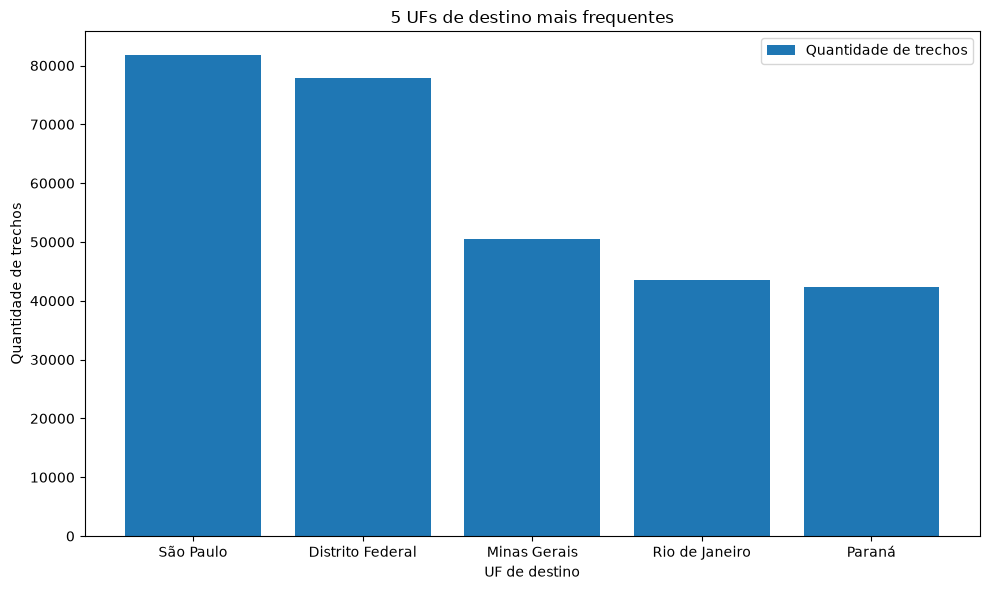

In [43]:
df_6_grafico = df_6.head(5)

plt.figure(figsize=(10, 6))

plt.bar(
    df_6_grafico["destino_uf"],
    df_6_grafico["quantidade"],
    label="Quantidade de trechos"
)

plt.title("5 UFs de destino mais frequentes")
plt.xlabel("UF de destino")
plt.ylabel("Quantidade de trechos")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão

São Paulo foi a UF de destino que apareceu com maior frequência nos trechos das viagens realizadas, com 81.727 registros.

### 4.7 Qual órgão pagou mais no total?

In [44]:
consulta_7 = text("""
SELECT
    p.nome_orgao_pagador AS orgao_pagador,
    SUM(p.valor) AS total_pago
FROM public.silver_pagamento p
JOIN public.silver_viagem v
    ON p.id_viagem = v.id_viagem
WHERE v.situacao = 'Realizada'
GROUP BY p.nome_orgao_pagador
ORDER BY total_pago DESC;
""")

df_7 = pd.read_sql(consulta_7, engine)

df_7_exibicao = df_7.copy()
df_7_exibicao["total_pago"] = df_7_exibicao["total_pago"].apply(moeda)

display(df_7_exibicao.head(5))

,orgao_pagador,total_pago
0,Fundo Nacional de Segurança Pública,"R$ 278.288.685,42"
1,Sigiloso,"R$ 199.308.482,09"
2,Comando da Aeronáutica,"R$ 81.069.602,67"
3,Instituto Nacional do Seguro Social,"R$ 37.254.697,89"
4,Comando do Exército,"R$ 36.576.135,70"


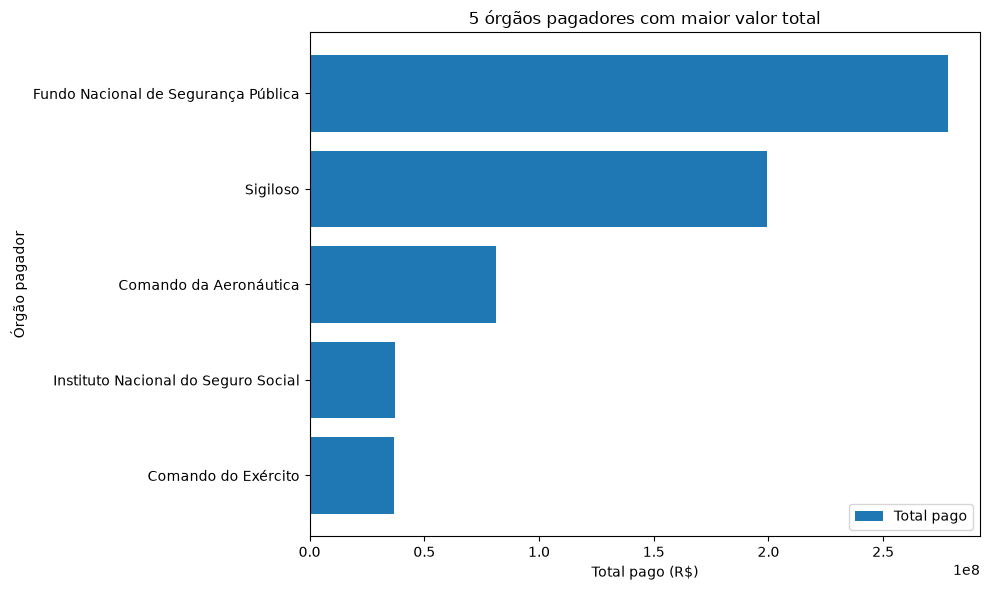

In [45]:
df_7_grafico = df_7.head(5)

plt.figure(figsize=(10, 6))

plt.barh(
    df_7_grafico["orgao_pagador"][::-1],
    df_7_grafico["total_pago"][::-1],
    label="Total pago"
)

plt.title("5 órgãos pagadores com maior valor total")
plt.xlabel("Total pago (R$)")
plt.ylabel("Órgão pagador")
plt.legend()
plt.tight_layout()
plt.show()

### Conclusão

O Fundo Nacional de Segurança Pública apresentou o maior valor total pago entre os órgãos pagadores analisados.

## 5. Agregação da camada GOLD

In [46]:
consulta_gold = text("""
SELECT
    orgao,
    quantidade_viagens,
    quantidade_trechos
FROM public.vw_gold_resumo_trechos
ORDER BY quantidade_trechos DESC
LIMIT 10;
""")

df_gold = pd.read_sql(consulta_gold, engine)

display(df_gold)

,orgao,quantidade_viagens,quantidade_trechos
0,Ministério da Defesa,61351,160480
1,Ministério da Educação,64739,151208
2,Ministério da Justiça e Segurança Pública,24803,94924
3,Ministério do Meio Ambiente e Mudança do Clima,19165,57998
4,Ministério do Planejamento e Orçamento,18148,42690
5,Sem informação,14695,40608
6,Ministério da Fazenda,11413,24752
7,Ministério do Desenvolvimento Agrário e Agricu...,8472,22736
8,Ministério da Previdência Social,8125,21308
9,Ministério da Saúde,8440,20585


## 6. Limitações

Os dados analisados abrangem o período de janeiro a junho de 2025.

Os resultados representam apenas o período disponível na base analisada e não devem ser generalizados para períodos que não estão presentes nos dados.

O campo de destino é um texto livre. Por isso, destinos com formas de escrita diferentes podem ser considerados categorias distintas.

## 7. Conclusão geral

A análise dos dados de viagens de 2025 permitiu identificar padrões relacionados aos custos, pagamentos, duração, meios de transporte e destinos.

O Ministério da Justiça e Segurança Pública apresentou o maior custo total entre os órgãos analisados.

Brasília/DF, Brasília/DF apresentou o maior custo médio por viagem entre os destinos com pelo menos 100 viagens.

A viagem com maior duração apresentou 384 dias e custo registrado de R$ 0,00.

As diárias apresentaram o maior valor médio entre os tipos de pagamento.

O Veículo Oficial foi o meio de transporte mais utilizado nos trechos, enquanto São Paulo foi a UF de destino mais frequente.

O Fundo Nacional de Segurança Pública apresentou o maior total pago entre os órgãos pagadores.

As análises foram realizadas utilizando Python, SQL e PostgreSQL, com visualizações desenvolvidas por meio das bibliotecas Matplotlib e Seaborn.